# Feature-axis validation — is `design_name` really the right client axis?

Encode the CircuitNet-N28 factorial design matrix (one-hot `design_name` + the six other metadata knobs),
PCA it, and then run variance decomposition + three geometric probes to see
which factor structures the shared metadata space. Whichever factor consistently
dominates earns the FL client axis.

## Workflow

1. Parse filenames into a factorial design matrix.
2. One-hot `design_name`, then QuantileTransform + StandardScaler + 12-component PCA.
3. Print top loadings + recolor PC1/PC2 by each factor.
4. Variance-weighted η² decomposition per factor across all 12 PCs.
5. Clustering + neighborhood probes on the first 3 PCs: K-means, Ward
   hierarchical, kNN label agreement.
6. Final verdict + references.

# Imports

In [2]:
import os, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm

from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import chi2_contingency

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5', 'figure.facecolor': 'white',
})

FEATURE_DIR = '../routability_ir_drop_prediction/training_set_N28/DRC/feature'
SEED = 42
N_PER_STRATUM = 12
STRATUM_COLS  = ['design_name','clock_ns','utilization']
print('Imports OK.')

Imports OK.


# Parse filenames 

In [3]:
def parse_sample_name(filename: str) -> dict:
    basename = filename.replace('.npy', '')
    parts = basename.split('-')
    if parts[0].isdigit():
        parts = parts[1:]
    for expected, token in zip(['c','u','m','p','f'], parts[-5:]):
        if not token.startswith(expected):
            raise ValueError(f'Bad token {token} in {filename}')
    c, u, m, p, f = parts[-5:]

    design_name = '-'.join(parts[:-6])
    variant = design_name.split('-')[-1]
    macro_count = int(parts[-6])

    if not macro_count:
        macro_count = 1

    if variant == 'a' and macro_count in (1, 2, 3):
        macro_count += 2
    if variant == 'b':
        if macro_count in (1, 2, 3):
            macro_count += 12
        else:
            macro_count += 10

    return {
        'design_name':      design_name,
        'macro_count':      macro_count,
        'clock_ns':         float(c[1:]),
        'utilization':      float(u[1:]),
        'macro_placement':  m[1:],
        'power_mesh':       p[1:],
        'filler_insertion': f[1:],
        'filename':         filename,
    }

files = sorted(f for f in os.listdir(FEATURE_DIR) if f.endswith('.npy'))
df_meta = pd.DataFrame([parse_sample_name(f) for f in files])
df_meta.loc[~df_meta['macro_placement'].isin(['1','2','3','4']), 'macro_placement'] = '1'

FACTOR_COLS = ['design_name','macro_count','clock_ns',
               'utilization','macro_placement','power_mesh','filler_insertion']
print(f'Samples: {len(df_meta)}')
print('Unique-value counts per factor:')
for c in FACTOR_COLS:
    print(f'  {c:20s} {df_meta[c].nunique():3d}')

Samples: 10242
Unique-value counts per factor:
  design_name            6
  macro_count            6
  clock_ns               3
  utilization            5
  macro_placement        4
  power_mesh             8
  filler_insertion       2


# Factor level frequencies

Factor level frequencies   (n = 10242 samples)

--- design_name   (6 levels) ---
              count  percent
design_name                 
RISCY-FPU-a    1969    19.22
RISCY-FPU-b    1248    12.19
RISCY-a        2003    19.56
RISCY-b        1858    18.14
zero-riscy-a   2042    19.94
zero-riscy-b   1122    10.95

--- macro_count   (6 levels) ---
             count  percent
macro_count                
3             2273    22.19
4             1815    17.72
5             1926    18.80
13            1588    15.50
14            1275    12.45
15            1365    13.33

--- clock_ns   (3 levels) ---
          count  percent
clock_ns                
2.0        3250    31.73
5.0        4172    40.73
20.0       2820    27.53

--- utilization   (5 levels) ---
             count  percent
utilization                
0.7           2269    22.15
0.75          2262    22.09
0.8           2216    21.64
0.85          1962    19.16
0.9           1533    14.97

--- macro_placement   (4 levels) ---
     


--- power_mesh   (8 levels) ---
            count  percent
power_mesh                
1            1273    12.43
2            1255    12.25
3            1271    12.41
4            1264    12.34
5            1298    12.67
6            1302    12.71
7            1292    12.61
8            1287    12.57

--- filler_insertion   (2 levels) ---
                  count  percent
filler_insertion                
0                  4385    42.81
1                  5857    57.19

--- balance summary   (imbalance = max/min level count) ---
                  levels  min_count  max_count  imbalance
factor                                                   
design_name            6       1122       2042       1.82
macro_count            6       1275       2273       1.78
clock_ns               3       2820       4172       1.48
utilization            5       1533       2269       1.48
macro_placement        4        705       3422       4.85
power_mesh             8       1255       1302       1.04
f

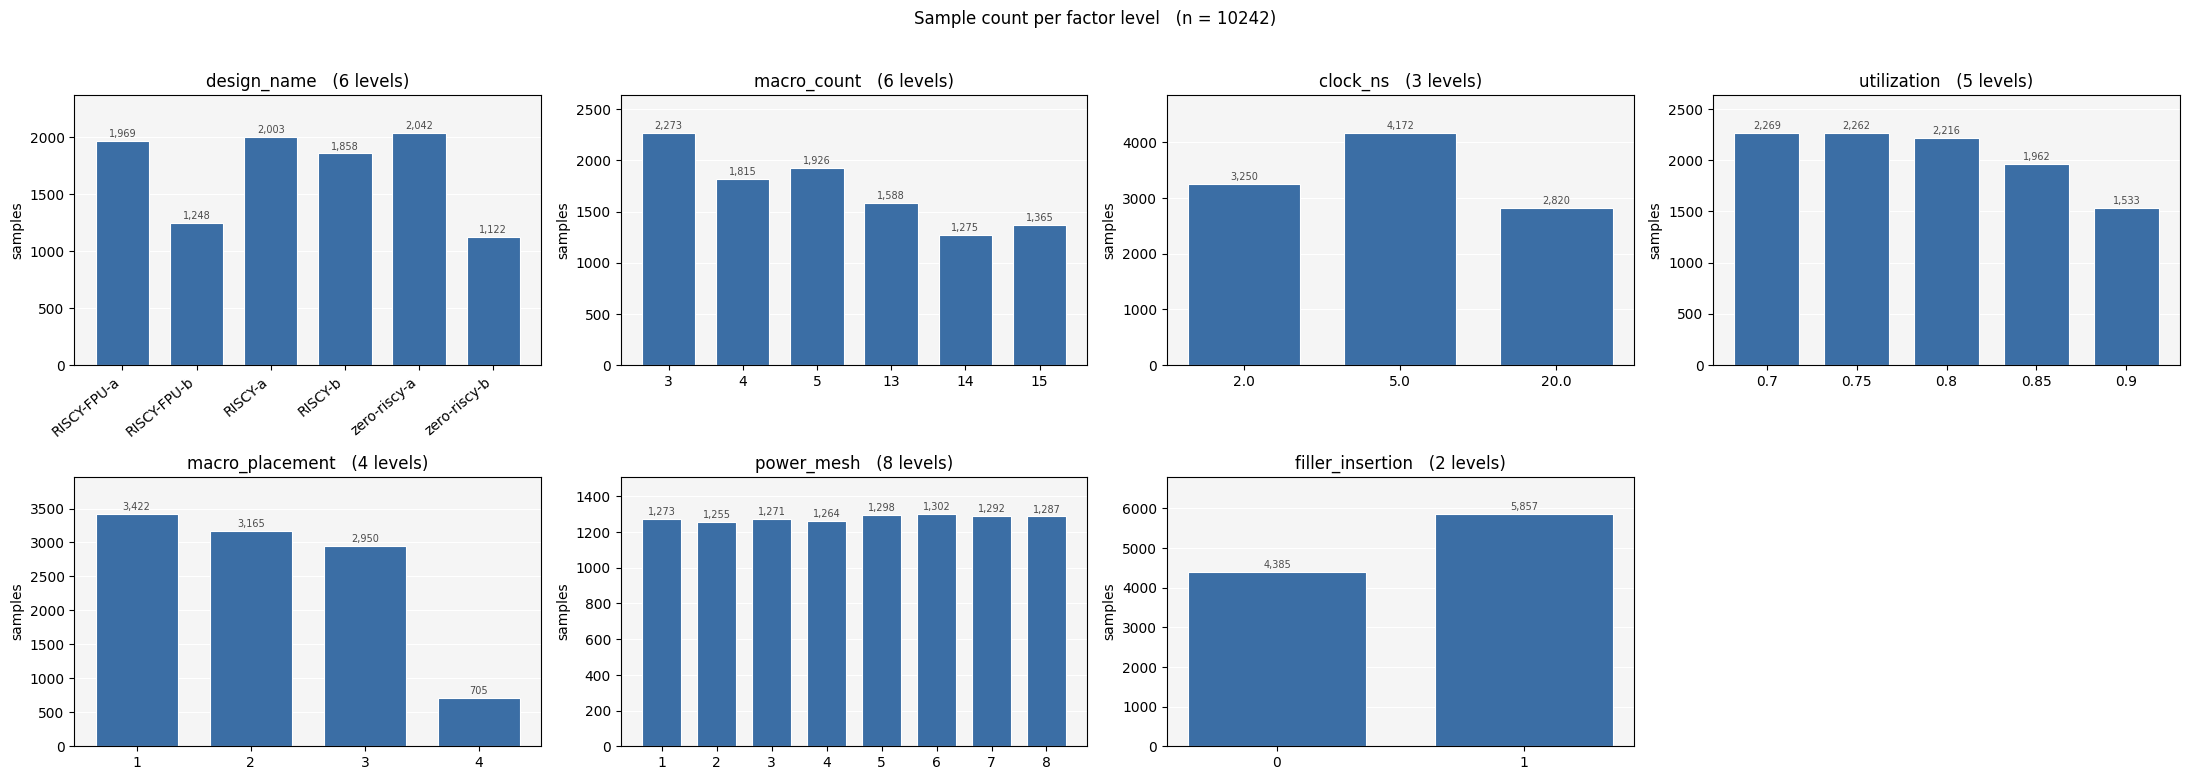

In [4]:
BAR_COLOR = '#3b6ea5'


def factor_levels(series):
    """Level labels of a factor, numerically ordered when possible."""
    vals = series.astype(str).unique()
    try:
        return sorted(vals, key=float)
    except ValueError:
        return sorted(vals)


def frequency_table(df, col):
    """Sample count and share of the corpus per level of `col`."""
    levels = factor_levels(df[col])
    counts = (df[col].astype(str).value_counts()
              .reindex(levels).fillna(0).astype(int))
    tbl = pd.DataFrame({'count': counts})
    tbl['percent'] = (tbl['count'] / len(df) * 100).round(2)
    tbl.index.name = col
    return tbl


def print_frequency_tables(df, factor_cols):
    print('=' * 72)
    print(f'Factor level frequencies   (n = {len(df)} samples)')
    print('=' * 72)
    balance = []
    for f in factor_cols:
        tbl = frequency_table(df, f)
        print(f'\n--- {f}   ({len(tbl)} levels) ---')
        print(tbl.to_string())
        balance.append({
            'factor':    f,
            'levels':    len(tbl),
            'min_count': int(tbl['count'].min()),
            'max_count': int(tbl['count'].max()),
            'imbalance': round(tbl['count'].max() / max(tbl['count'].min(), 1), 2),
        })
    print('\n--- balance summary   (imbalance = max/min level count) ---')
    print(pd.DataFrame(balance).set_index('factor').to_string())


def plot_factor_frequencies(df, factor_cols, ncols=4, color=BAR_COLOR):
    nrows = int(np.ceil(len(factor_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, f in zip(axes, factor_cols):
        tbl = frequency_table(df, f)
        levels = [str(x) for x in tbl.index]
        xs = np.arange(len(levels))
        ax.bar(xs, tbl['count'], width=0.72, color=color,
               edgecolor='white', linewidth=0.8)
        for x, n in zip(xs, tbl['count']):
            ax.annotate(f'{n:,}', (x, n), textcoords='offset points',
                        xytext=(0, 3), ha='center', fontsize=7, color='#4a4a4a')
        ax.set_xticks(xs)
        ax.set_xticklabels(levels)
        if max(len(l) for l in levels) > 6:
            ax.tick_params(axis='x', labelrotation=40)
            for lab in ax.get_xticklabels():
                lab.set_ha('right')
        ax.set_title(f'{f}   ({len(levels)} levels)')
        ax.set_ylabel('samples')
        ax.set_ylim(0, tbl['count'].max() * 1.16)
        ax.set_axisbelow(True)
        ax.xaxis.grid(False)
    for ax in axes[len(factor_cols):]:
        ax.axis('off')
    fig.suptitle(f'Sample count per factor level   (n = {len(df)})', y=1.02)
    plt.tight_layout(); plt.show()


print_frequency_tables(df_meta, FACTOR_COLS)
plot_factor_frequencies(df_meta, FACTOR_COLS)

# Preprocess + PCA

One-hot `design_name` (6 columns) and keep the other six factors as numeric
codes. `QuantileTransformer` maps every column to a Gaussian marginal so no
single knob dominates purely by scale, then `StandardScaler` re-centers, then
a 12-component PCA (the design matrix has 12 columns after one-hot, so 12 PCs
capture the entire variance; PC12 is numerically zero because of the one-hot
sum-to-one collinearity).

Twelve components are kept regardless of any explained-variance elbow because
the variance-decomposition below needs a fixed PC set across every factor to
be comparable.

Index(['macro_count', 'clock_ns', 'utilization', 'macro_placement',
       'power_mesh', 'filler_insertion', 'design_name_RISCY-FPU-a',
       'design_name_RISCY-FPU-b', 'design_name_RISCY-a', 'design_name_RISCY-b',
       'design_name_zero-riscy-a', 'design_name_zero-riscy-b'],
      dtype='object')
Explained variance ratio:
  PC 1: 0.190   cumulative=0.190
  PC 2: 0.105   cumulative=0.295
  PC 3: 0.104   cumulative=0.399
  PC 4: 0.103   cumulative=0.502
  PC 5: 0.095   cumulative=0.597
  PC 6: 0.094   cumulative=0.691
  PC 7: 0.084   cumulative=0.775
  PC 8: 0.083   cumulative=0.858
  PC 9: 0.074   cumulative=0.932
  PC10: 0.067   cumulative=0.999
  PC11: 0.001   cumulative=1.000
  PC12: 0.000   cumulative=1.000


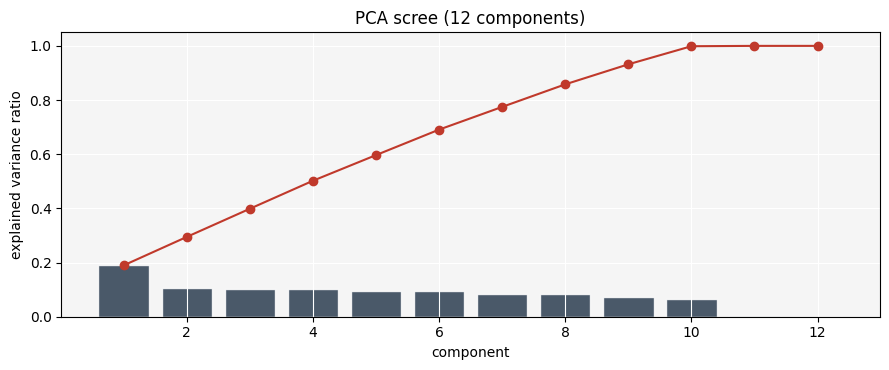

In [5]:
subset = df_meta
new_subset = pd.get_dummies(subset, columns=['design_name'], dtype='uint8')
new_subset = new_subset.drop(columns=['filename'])
print(new_subset.columns)

X = new_subset[new_subset.columns].to_numpy()

qt = QuantileTransformer(output_distribution='normal', random_state=SEED,
                         n_quantiles=min(1000, len(X)))
X_qt = qt.fit_transform(X)
sc = StandardScaler()
X_std = sc.fit_transform(X)

N_PC = X_std.shape[1]
pca = PCA(n_components=N_PC, random_state=SEED)
Z = pca.fit_transform(X_std)
evr = pca.explained_variance_ratio_
print('Explained variance ratio:')
for i, v in enumerate(evr):
    print(f'  PC{i + 1:2d}: {v:.3f}   cumulative={evr[:i + 1].sum():.3f}')

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(range(1, N_PC + 1), evr, alpha=0.85, color='#2c3e50', edgecolor='white')
ax.plot(range(1, N_PC + 1), np.cumsum(evr), marker='o', color='#c0392b')
ax.set_xlabel('component'); ax.set_ylabel('explained variance ratio')
ax.set_title('PCA scree (' + str(N_PC) + ' components)')
plt.tight_layout()
plt.show()

# PC loadings + recolored PC1/PC2 scatter

Print the top-10 columns by absolute loading on PC1/PC2/PC3, then plot the
same PC1/PC2 scatter recolored by five metadata factors. A factor that
produces visibly separated clusters is one the leading PCs encode directly.


Top-10 |loadings| on PC1:
  +0.648  macro_count
  +0.363  design_name_RISCY-b
  +0.295  design_name_RISCY-FPU-b
  -0.273  design_name_zero-riscy-a
  -0.267  design_name_RISCY-a
  +0.265  design_name_zero-riscy-b
  -0.264  design_name_RISCY-FPU-a
  -0.183  macro_placement
  +0.156  filler_insertion
  +0.109  utilization

Top-10 |loadings| on PC2:
  +0.575  design_name_RISCY-b
  -0.435  filler_insertion
  -0.406  design_name_zero-riscy-a
  -0.363  design_name_RISCY-FPU-b
  -0.230  utilization
  -0.208  design_name_zero-riscy-b
  +0.207  design_name_RISCY-a
  +0.162  macro_placement
  +0.107  design_name_RISCY-FPU-a
  +0.074  macro_count

Top-10 |loadings| on PC3:
  +0.667  design_name_zero-riscy-a
  -0.541  design_name_RISCY-a
  +0.341  design_name_RISCY-b
  -0.230  design_name_RISCY-FPU-b
  -0.178  filler_insertion
  -0.173  design_name_RISCY-FPU-a
  -0.127  design_name_zero-riscy-b
  +0.101  clock_ns
  +0.057  macro_placement
  -0.032  utilization


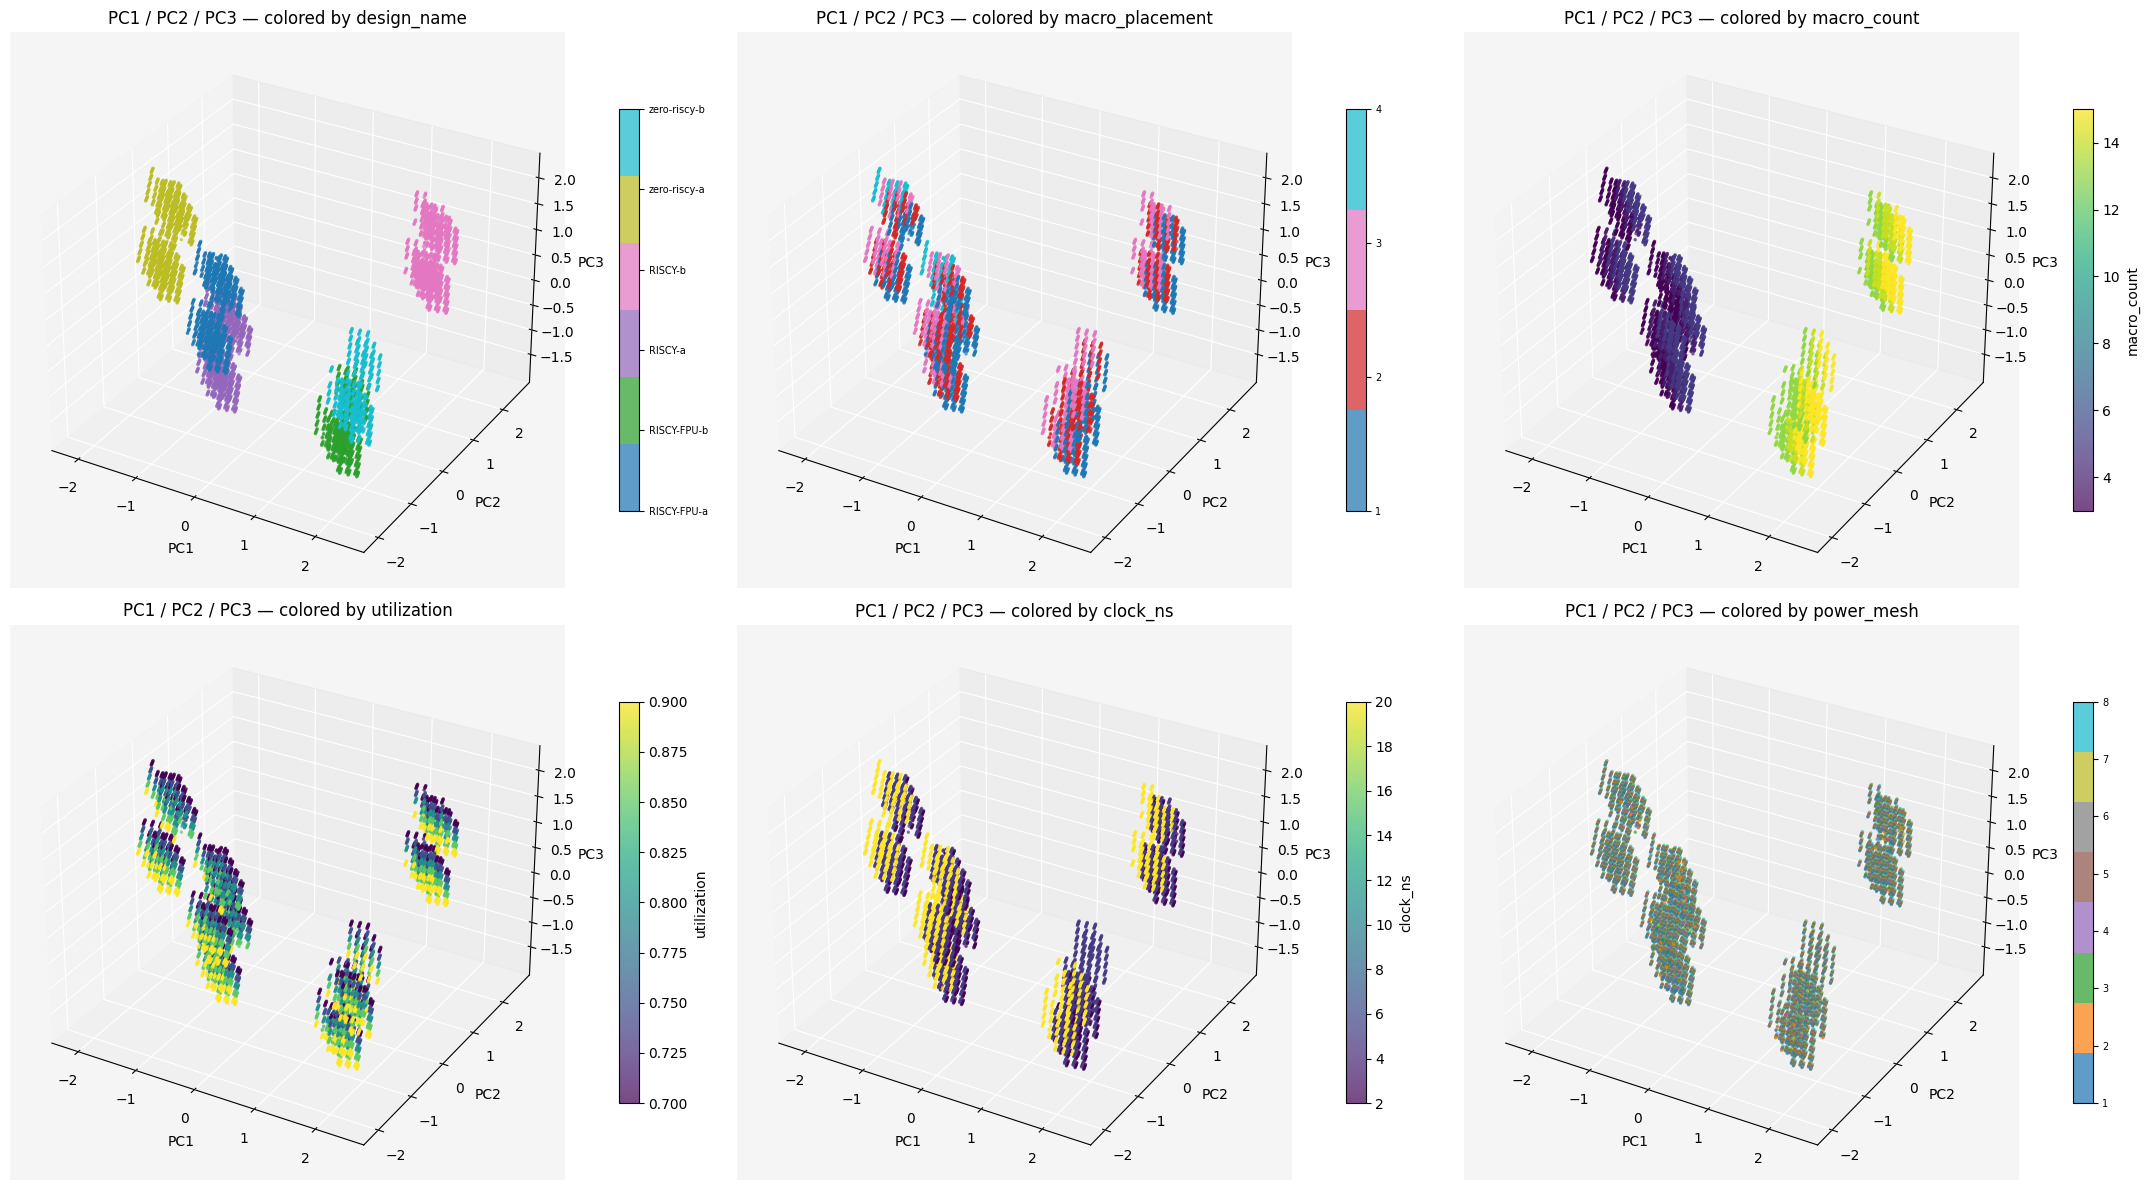

In [6]:
loadings = pd.DataFrame(pca.components_.T, index=new_subset.columns,
                        columns=[f'PC{i + 1}' for i in range(pca.n_components_)])

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(10)
    print(f'\nTop-10 |loadings| on {pc}:')
    for name in top.index:
        print(f'  {loadings.loc[name, pc]:+.3f}  {name}')

recolor_factors = ['design_name', 'macro_placement', 'macro_count',
                   'utilization', 'clock_ns', 'power_mesh']
fig = plt.figure(figsize=(22, 12))
for i, factor in enumerate(recolor_factors):
    ax = fig.add_subplot(2, 3, i + 1, projection='3d')
    if pd.api.types.is_numeric_dtype(subset[factor]):
        codes = subset[factor].to_numpy()
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=codes, cmap='viridis',
                         s=6, alpha=0.7, edgecolor='none', depthshade=False)
        plt.colorbar(sc_, ax=ax, fraction=0.03, pad=0.08, label=factor)
    else:
        levels = sorted(subset[factor].astype(str).unique())
        code_map = {l: i for i, l in enumerate(levels)}
        codes = subset[factor].astype(str).map(code_map).to_numpy()
        cmap = mcm.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=codes, cmap=cmap,
                         s=6, alpha=0.7, edgecolor='none', depthshade=False,
                         vmin=0, vmax=max(len(levels) - 1, 1))
        cbar = plt.colorbar(sc_, ax=ax, ticks=range(len(levels)),
                            fraction=0.03, pad=0.08)
        cbar.set_ticklabels(levels)
        cbar.ax.tick_params(labelsize=7)
    ax.set_title(f'PC1 / PC2 / PC3 — colored by {factor}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
plt.tight_layout()
plt.show()

df_full = subset

# Variance decomposition — variance-weighted η² on the leading PCs

Instead of PERMANOVA (which needs an n × n distance matrix), compute per-PC
η² of each factor via one-way ANOVA and sum the contributions weighted by
that PC's explained variance. The `weighted_total` column approximates the
*fraction of factorial-design variance explained by that factor*. Balanced
factorial ⇒ these numbers can be read semi-quantitatively.

          factor  n_levels  eta2_PC1  eta2_PC2  eta2_PC3  eta2_PC4  eta2_PC5  eta2_PC6  eta2_PC7  eta2_PC8  eta2_PC9  eta2_PC10  eta2_PC11  eta2_PC12  weighted_total
     design_name         6     0.958     0.757     0.963     0.997     0.461     0.697     0.083     0.004     0.037      0.038      0.006        0.0           0.586
     macro_count         6     0.964     0.015     0.005     0.000     0.015     0.009     0.008     0.001     0.014      0.007      0.991        0.0           0.191
 macro_placement         4     0.114     0.039     0.005     0.001     0.240     0.083     0.038     0.001     0.380      0.207      0.000        0.0           0.102
        clock_ns         3     0.024     0.001     0.013     0.002     0.250     0.171     0.138     0.002     0.411      0.040      0.000        0.0           0.091
filler_insertion         2     0.055     0.239     0.040     0.000     0.119     0.075     0.020     0.002     0.003      0.447      0.000        0.0           0.090
    

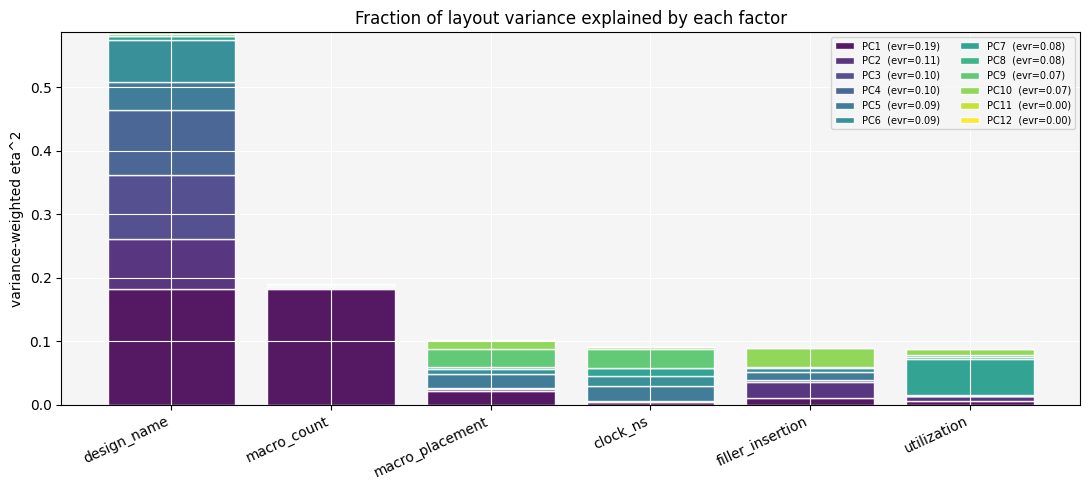

In [7]:
def eta_sq(y_num, groups):
    d = pd.DataFrame({'y': y_num, 'g': groups}).dropna()
    grand = d['y'].mean()
    ss_tot = ((d['y'] - grand) ** 2).sum()
    if ss_tot == 0:
        return 0.0
    ss_bet = sum(len(g) * (g['y'].mean() - grand) ** 2
                 for _, g in d.groupby('g'))
    return float(ss_bet / ss_tot)


K_PC = pca.n_components_
eta_rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    groups = df_full[f].astype(str).to_numpy()
    row = {'factor': f, 'n_levels': int(df_full[f].nunique())}
    for k in range(K_PC):
        row[f'eta2_PC{k + 1}'] = round(eta_sq(Z[:, k], groups), 3)
    row['weighted_total'] = round(sum(
        row[f'eta2_PC{k + 1}'] * evr[k] for k in range(K_PC)
    ), 3)
    eta_rows.append(row)
eta_df = pd.DataFrame(eta_rows).sort_values('weighted_total', ascending=False)
print(eta_df.to_string(index=False))

top_factors = eta_df.head(6)['factor'].tolist()
fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(top_factors))
cmap = mcm.get_cmap('viridis', K_PC)
for k in range(K_PC):
    heights = np.array([
        eta_df.set_index('factor').loc[f, f'eta2_PC{k + 1}'] * evr[k]
        for f in top_factors
    ])
    ax.bar(top_factors, heights, bottom=bottom, color=cmap(k),
           label=f'PC{k + 1}  (evr={evr[k]:.2f})',
           edgecolor='white', alpha=0.9)
    bottom += heights
ax.set_ylabel('variance-weighted eta^2')
ax.set_title('Fraction of layout variance explained by each factor')
ax.legend(fontsize=7, loc='upper right', ncol=2)
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()

# Clustering + neighborhood diagnostics on the first 3 PCs

Order:

1. **K-means** — k sweep with silhouette; ARI/NMI at the best-silhouette k
   against every metadata factor.
2. **Hierarchical (Ward)** — dendrogram + ARI/NMI at the same k. Tests
   whether the metadata hierarchy sits at the top of the tree, and cross-
   checks the k-means partition with a different objective.
3. **kNN label agreement** — for each factor, fraction of a sample's k
   nearest neighbors that share its label, vs chance. Model-free, no k to
   pick beyond the neighborhood size, and gives a per-factor number without
   needing to assume a partition.

## K-means — k sweep + label agreement

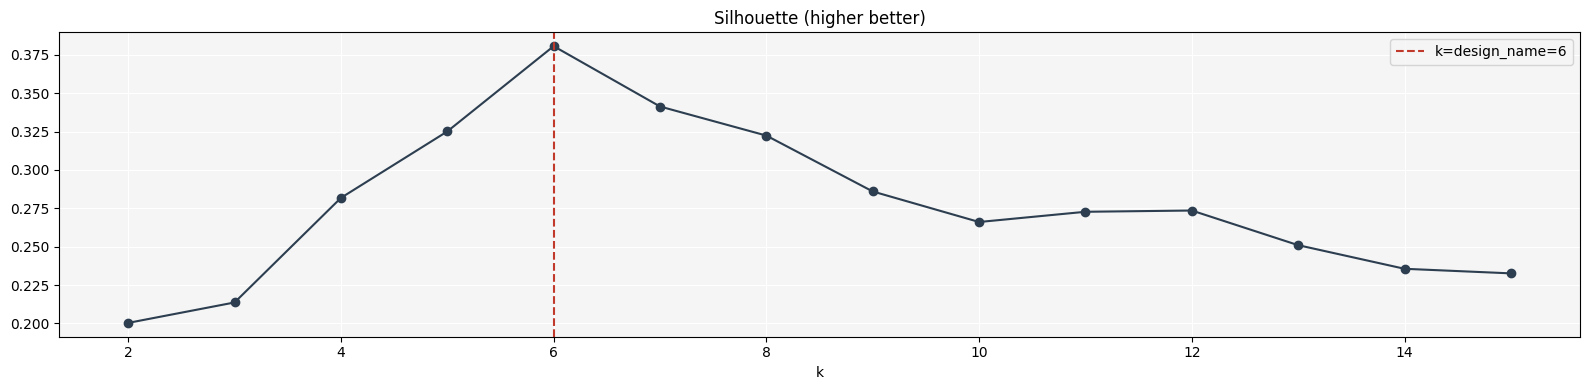

Best-silhouette k = 6   (silhouette = 0.381)
design_name    k = 6   (silhouette = 0.381)


In [8]:
Z3 = Z
k_design = df_full['design_name'].nunique()

ks = list(range(2, 16))
sil, dbi, inertia = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lab = km.fit_predict(Z3)
    sil.append(silhouette_score(Z3, lab))

k_best_sil = ks[int(np.argmax(sil))]
fig, axes = plt.subplots(1, 1, figsize=(16, 4))
axes.plot(ks, sil, marker='o', color='#2c3e50')
axes.axvline(k_best_sil, ls='--', color='#c0392b', label=f'k=design_name={k_design}')
axes.set_title('Silhouette (higher better)')
axes.set_xlabel('k')
axes.legend()
plt.tight_layout(); plt.show()

print(f'Best-silhouette k = {k_best_sil}   (silhouette = {max(sil):.3f})')
print(f'design_name    k = {k_design}   (silhouette = {sil[ks.index(k_design)]:.3f})')


In [9]:
# SET K HERE
k_design = 6
print(f'Using k_design = {k_design} for clustering and evaluation.')

Using k_design = 6 for clustering and evaluation.



ARI / NMI of k-means labels (k=6) vs each metadata factor:
  design_name          ARI=+1.000  NMI=1.000
  macro_count          ARI=+0.200  NMI=0.386
  clock_ns             ARI=+0.006  NMI=0.015
  utilization          ARI=+0.003  NMI=0.004
  macro_placement      ARI=+0.000  NMI=0.026
  power_mesh           ARI=-0.001  NMI=0.000
  filler_insertion     ARI=+0.003  NMI=0.010


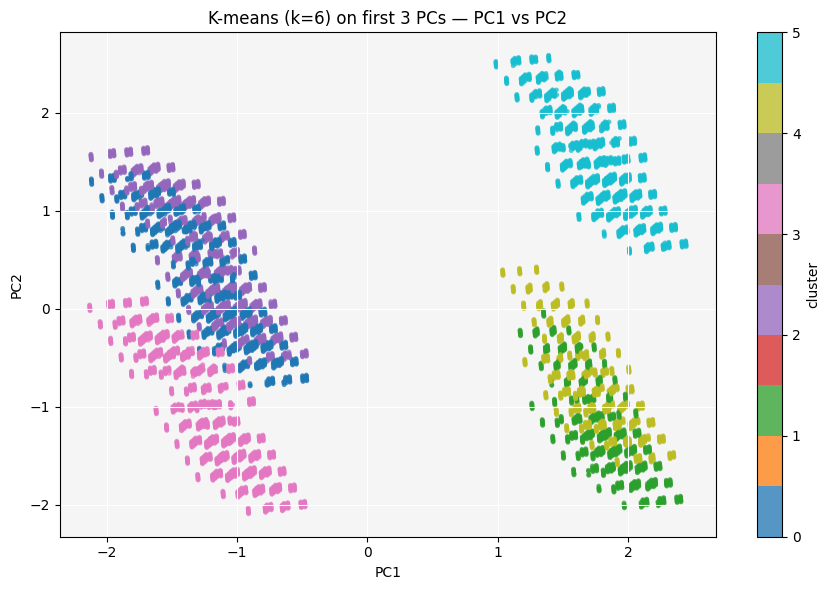

In [10]:
km = KMeans(n_clusters=k_design, n_init=10, random_state=SEED)
lab_km = km.fit_predict(Z3)
print(f'\nARI / NMI of k-means labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_km)
    nmi = normalized_mutual_info_score(y, lab_km)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')
k_design = 6

fig, ax = plt.subplots(figsize=(9, 6))
sc_ = ax.scatter(Z3[:, 0], Z3[:, 1], c=lab_km, cmap='tab10',
                 s=12, alpha=0.75, edgecolor='none')
ax.set_title(f'K-means (k={k_design}) on first 3 PCs — PC1 vs PC2')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(sc_, ax=ax, label='cluster')
plt.tight_layout()
plt.show()

## Hierarchical (Ward) — dendrogram + label agreement

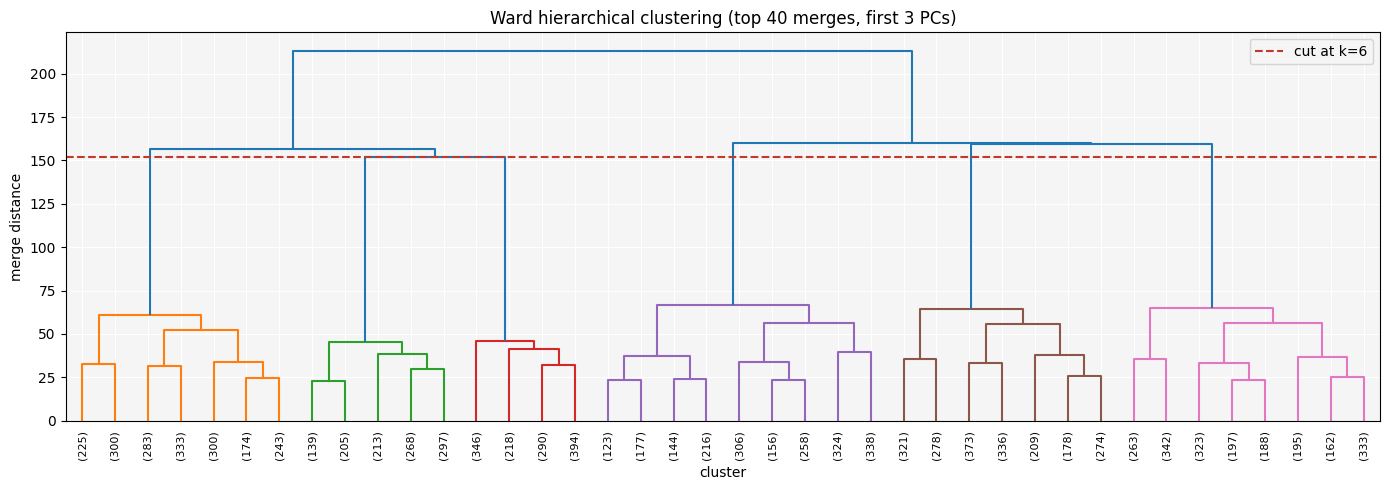

Hierarchical @ k=6  silhouette = 0.381   (k-means @ k=6 silhouette = 0.381)

ARI / NMI of hierarchical labels (k=6) vs each metadata factor:
  design_name          ARI=+1.000  NMI=1.000
  macro_count          ARI=+0.200  NMI=0.386
  clock_ns             ARI=+0.006  NMI=0.015
  utilization          ARI=+0.003  NMI=0.004
  macro_placement      ARI=+0.000  NMI=0.026
  power_mesh           ARI=-0.001  NMI=0.000
  filler_insertion     ARI=+0.003  NMI=0.010


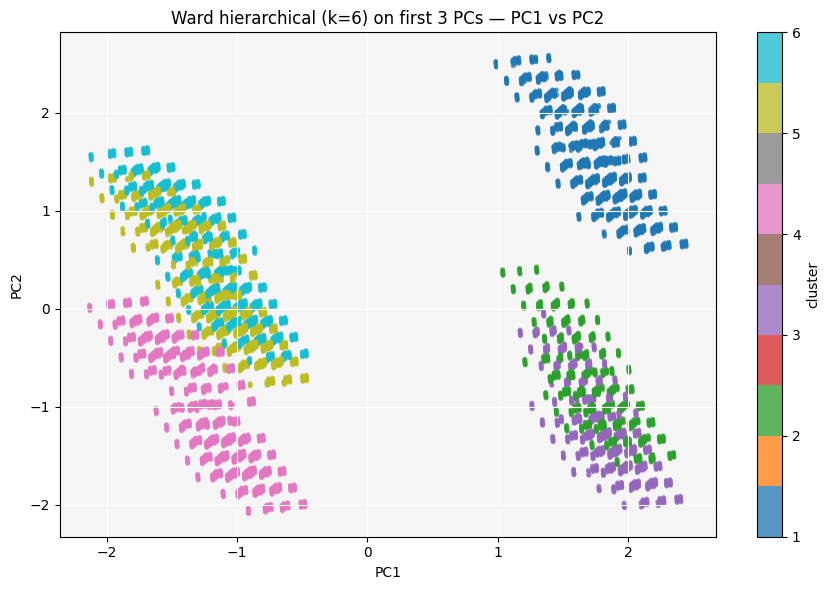

In [11]:
Z_link = linkage(Z3, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z_link, 
    truncate_mode='lastp', 
    p=40,
    leaf_rotation=90, 
    leaf_font_size=8, 
    ax=ax,
    color_threshold=Z_link[-(k_design - 1), 2]
)
ax.axhline(
    Z_link[-(k_design - 1), 2], 
    ls='--', 
    color='#c0392b',
    label=f'cut at k={k_design}'
)
ax.set_title(f'Ward hierarchical clustering (top 40 merges, first 3 PCs)')
ax.set_xlabel('cluster')
ax.set_ylabel('merge distance')
ax.legend()
plt.tight_layout(); plt.show()

lab_hier = fcluster(Z_link, t=k_design, criterion='maxclust')
sil_hier = silhouette_score(Z3, lab_hier)
print(f'Hierarchical @ k={k_design}  silhouette = {sil_hier:.3f}   '
      f'(k-means @ k={k_design} silhouette = {sil[ks.index(k_design)]:.3f})')

print(f'\nARI / NMI of hierarchical labels (k={k_design}) vs each metadata factor:')
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    y = df_full[f].astype(str).to_numpy()
    ari = adjusted_rand_score(y, lab_hier)
    nmi = normalized_mutual_info_score(y, lab_hier)
    print(f'  {f:20s} ARI={ari:+.3f}  NMI={nmi:.3f}')

fig, ax = plt.subplots(figsize=(9, 6))
sc_ = ax.scatter(Z3[:, 0], Z3[:, 1], c=lab_hier, cmap='tab10',
                 s=12, alpha=0.75, edgecolor='none')
ax.set_title(f'Ward hierarchical (k={k_design}) on first 3 PCs — PC1 vs PC2')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.colorbar(sc_, ax=ax, label='cluster')
plt.tight_layout()
plt.show()

## Per-cluster feature distribution


K-means (k = 6): per-cluster feature distribution

Cluster sizes: {0: 1969, 1: 1248, 2: 2003, 3: 2042, 4: 1122, 5: 1858}   (total = 10242)

--- design_name   (% within each cluster) ---
design_name  RISCY-FPU-a  RISCY-FPU-b  RISCY-a  RISCY-b  zero-riscy-a  zero-riscy-b
cluster                                                                            
0                  100.0          0.0      0.0      0.0           0.0           0.0
1                    0.0        100.0      0.0      0.0           0.0           0.0
2                    0.0          0.0    100.0      0.0           0.0           0.0
3                    0.0          0.0      0.0      0.0         100.0           0.0
4                    0.0          0.0      0.0      0.0           0.0         100.0
5                    0.0          0.0      0.0    100.0           0.0           0.0

--- macro_count   (% within each cluster) ---
macro_count    13    14    15     3     4     5
cluster                                       

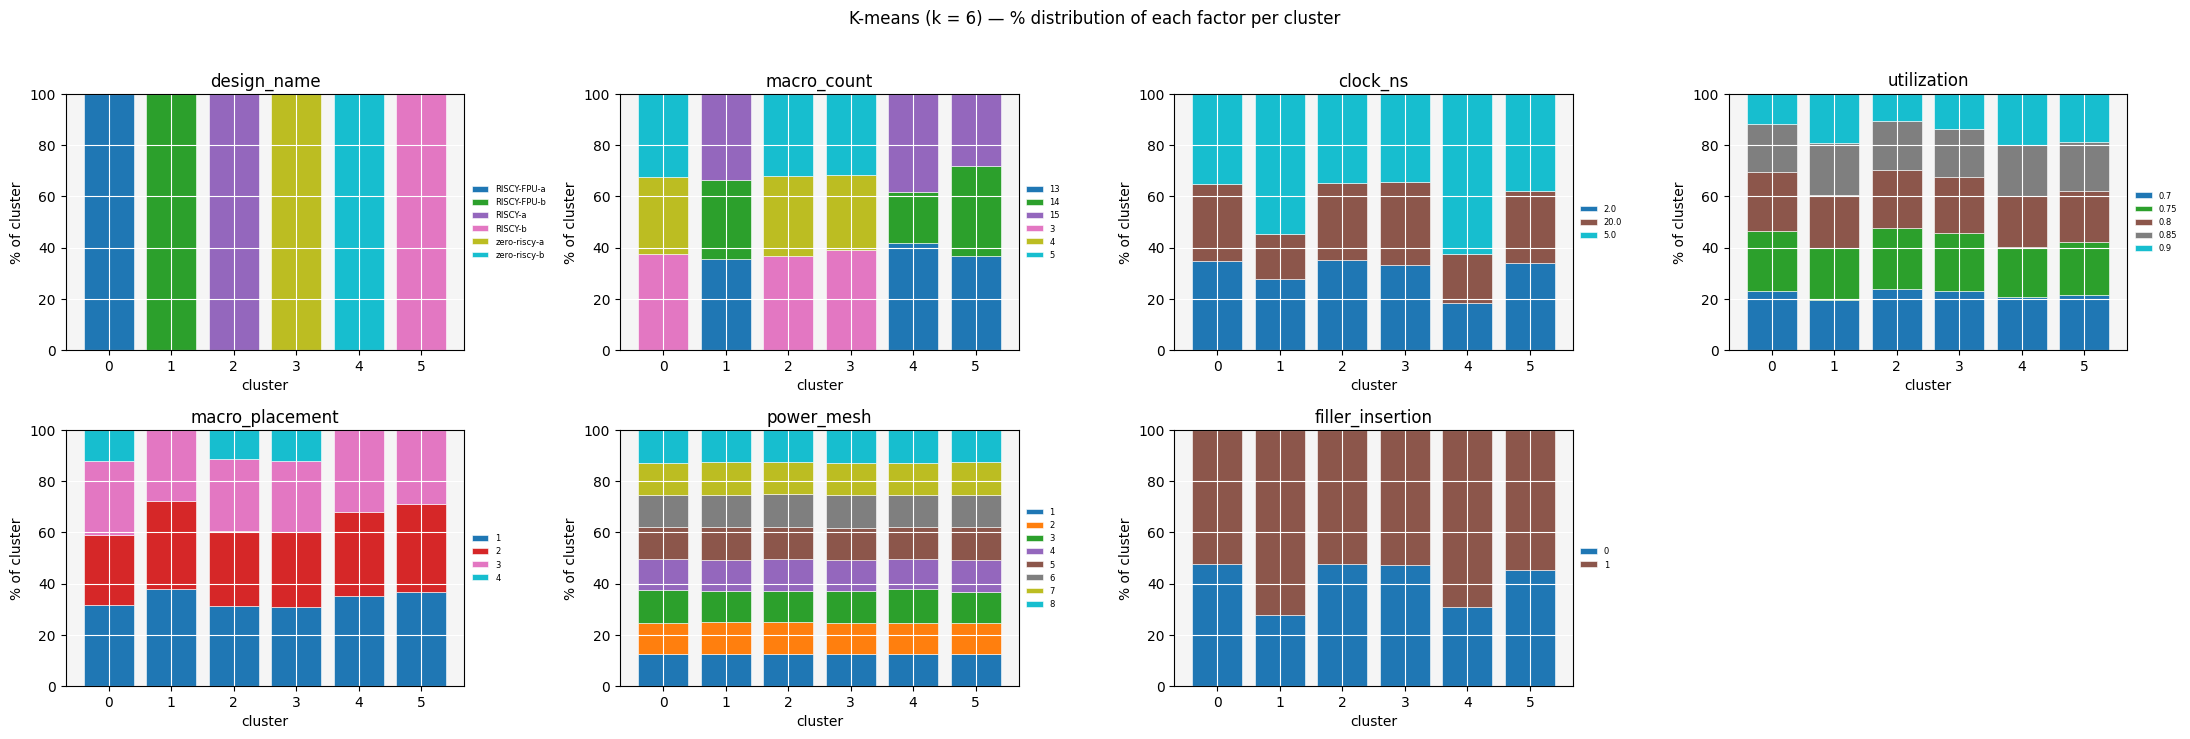

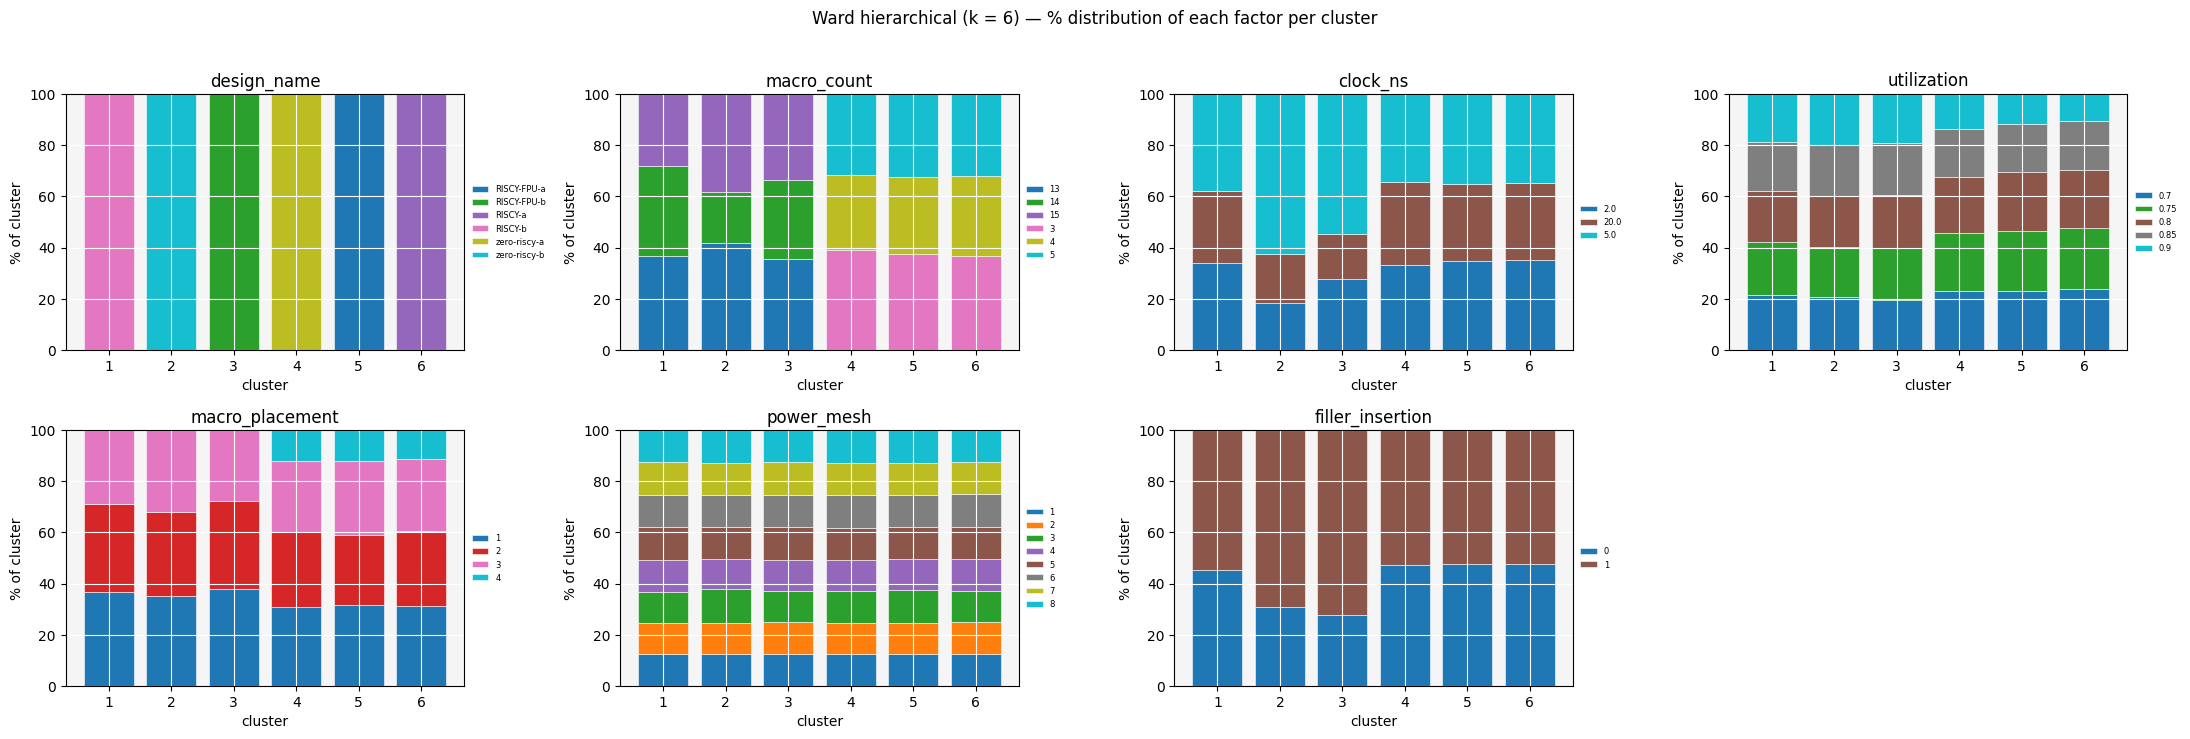

In [12]:
def per_cluster_tables(labels, method_name, df, factor_cols):
    lab_series = pd.Series(labels, name='cluster')
    sizes = lab_series.value_counts().sort_index()
    print(f'\n{"=" * 72}')
    print(f'{method_name}: per-cluster feature distribution')
    print(f'{"=" * 72}')
    print(f'\nCluster sizes: {dict(sizes)}   (total = {sizes.sum()})')
    for f in factor_cols:
        ct = pd.crosstab(lab_series, df[f].astype(str), normalize='index') * 100
        ct = ct.round(1)
        ct.index.name = 'cluster'
        print(f'\n--- {f}   (% within each cluster) ---')
        print(ct.to_string())


def plot_per_cluster(labels, method_name, df, factor_cols, ncols=4):
    cluster_ids = sorted(np.unique(labels))
    nfac = len(factor_cols)
    nrows = int(np.ceil(nfac / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3.6 * nrows))
    axes = axes.ravel()
    for i, f in enumerate(factor_cols):
        ax = axes[i]
        levels = sorted(df[f].astype(str).unique())
        counts = np.zeros((len(cluster_ids), len(levels)))
        for ci, c in enumerate(cluster_ids):
            mask = labels == c
            vc = df.loc[mask, f].astype(str).value_counts()
            for li, l in enumerate(levels):
                counts[ci, li] = vc.get(l, 0)
        row_sums = np.maximum(counts.sum(axis=1, keepdims=True), 1)
        pct = counts / row_sums * 100
        bottom = np.zeros(len(cluster_ids))
        cmap = plt.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        xtick = [str(c) for c in cluster_ids]
        for li, l in enumerate(levels):
            ax.bar(xtick, pct[:, li], bottom=bottom, color=cmap(li),
                   label=str(l), edgecolor='white', linewidth=0.4)
            bottom += pct[:, li]
        ax.set_title(f)
        ax.set_xlabel('cluster')
        ax.set_ylabel('% of cluster')
        ax.set_ylim(0, 100)
        ax.legend(fontsize=6, loc='center left', bbox_to_anchor=(1, 0.5),
                  frameon=False)
    for j in range(nfac, len(axes)):
        axes[j].axis('off')
    fig.suptitle(f'{method_name} — % distribution of each factor per cluster',
                 y=1.02)
    plt.tight_layout(); plt.show()


km_name   = f'K-means (k = {len(np.unique(lab_km))})'
hier_name = f'Ward hierarchical (k = {len(np.unique(lab_hier))})'

per_cluster_tables(lab_km,   km_name,   df_full, FACTOR_COLS)
per_cluster_tables(lab_hier, hier_name, df_full, FACTOR_COLS)

plot_per_cluster(lab_km,   km_name,   df_full, FACTOR_COLS)
plot_per_cluster(lab_hier, hier_name, df_full, FACTOR_COLS)

## kNN label agreement

For each sample take its `k` nearest neighbors in the first-3-PC space and,
for every metadata factor, compute the fraction of neighbors that share the
sample's label. Averaged over all samples, that fraction is the *local label
purity* of that factor in the descriptor geometry.

- **Agreement ≈ 1** ⇒ the factor is nearly perfectly encoded locally: a
  natural client axis for FL.
- **Agreement ≈ chance (= 1 / n_levels)** ⇒ the geometry says nothing about
  this factor; picking it as a client axis creates federated clients whose
  local data distributions are indistinguishable from IID.
- **Lift = agreement / chance** normalizes across factors with different
  cardinality, so `power_mesh` (8 levels, chance ≈ 0.125) and `design_name`
  (6 levels, chance ≈ 0.167) can be ranked on the same axis.

Model-free (no k to pick beyond the neighborhood size), cheap, and — unlike
k-means and Ward — gives a *per-factor* number without needing to assume a
partition. This is the diagnostic to trust most for the "which factor is the
client axis?" question.

In [13]:
K_range = [3, 5, 10, 15, 20, 30, 50]
records = []

for K in K_range:
    nn = NearestNeighbors(n_neighbors=K + 1).fit(Z3)
    _, idx = nn.kneighbors(Z3)
    neighbor_idx = idx[:, 1:]

    for f in FACTOR_COLS:
        if df_full[f].nunique() < 2:
            continue
        y = df_full[f].astype(str).to_numpy()
        match = (y[neighbor_idx] == y[:, None]).mean(axis=1)
        chance = 1.0 / df_full[f].nunique()
        records.append({
            'K': K, 'factor': f,
            'agreement': match.mean(),
            'lift': match.mean() / chance
        })

sweep_df = pd.DataFrame(records)
print("lift table")
display(sweep_df.pivot(index='K', columns='factor', values='lift').round(2))
print("agreements")
display(sweep_df.pivot(index='K', columns='factor', values='agreement').round(2))

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

print("\nCramér's V association matrix:\n")
cv_matrix = pd.DataFrame(index=FACTOR_COLS, columns=FACTOR_COLS, dtype=float)
for a in FACTOR_COLS:
    for b in FACTOR_COLS:
        if a == b:
            cv_matrix.loc[a, b] = 1.0
        else:
            cv_matrix.loc[a, b] = cramers_v(df_full[a].astype(str), df_full[b].astype(str))

print(cv_matrix.round(2).to_string())


lift table


factor,clock_ns,design_name,filler_insertion,macro_count,macro_placement,power_mesh,utilization
K,,,,,,,
3,2.38,6.0,2.0,2.39,4.00,6.42,4.94
5,2.46,6.0,2.0,2.92,4.00,4.39,4.86
10,2.29,6.0,2.0,2.10,3.98,3.73,4.33
15,2.11,6.0,2.0,2.25,3.94,3.26,3.81
20,2.15,6.0,2.0,2.31,3.88,3.32,3.26
30,2.20,6.0,2.0,2.34,3.69,3.07,2.68
50,2.13,6.0,2.0,2.23,3.22,2.55,2.48


agreements


factor,clock_ns,design_name,filler_insertion,macro_count,macro_placement,power_mesh,utilization
K,,,,,,,
3,0.79,1.0,1.0,0.40,1.00,0.80,0.99
5,0.82,1.0,1.0,0.49,1.00,0.55,0.97
10,0.76,1.0,1.0,0.35,0.99,0.47,0.87
15,0.70,1.0,1.0,0.38,0.99,0.41,0.76
20,0.72,1.0,1.0,0.38,0.97,0.42,0.65
30,0.73,1.0,1.0,0.39,0.92,0.38,0.54
50,0.71,1.0,1.0,0.37,0.81,0.32,0.50



Cramér's V association matrix:

                  design_name  macro_count  clock_ns  utilization  macro_placement  power_mesh  filler_insertion
design_name              1.00         0.45      0.15         0.05             0.13        0.01              0.15
macro_count              0.45         1.00      0.12         0.06             0.14        0.01              0.14
clock_ns                 0.15         0.12      1.00         0.03             0.06        0.01              0.11
utilization              0.05         0.06      0.03         1.00             0.04        0.01              0.14
macro_placement          0.13         0.14      0.06         0.04             1.00        0.01              0.32
power_mesh               0.01         0.01      0.01         0.01             0.01        1.00              0.02
filler_insertion         0.15         0.14      0.11         0.14             0.32        0.02              1.00
